# Notebook 6: Model Evaluation and Comparison

## Objective

This notebook automatically evaluates the SVM and LSTM models, compares their performance using multiple evaluation metrics, and identifies the best-performing model.

### Member

Pesara (CIT-24-01-0258)

### Models

- Support Vector Machine (SVM)
- Long Short-Term Memory (LSTM)

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# load clean dataset

In [2]:
news = pd.read_csv("../data/processed/clean_news.csv")

In [3]:
from sklearn.model_selection import train_test_split

X = news["text"]
y = news["label"]

X_train, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# SVM model

In [4]:
svm_model = joblib.load("../models/svm_model.pkl")

tfidf = joblib.load("../models/tfidf_vectorizer.pkl")

In [5]:
X_test_tfidf = tfidf.transform(X_test_text)

svm_predictions = svm_model.predict(X_test_tfidf)

# LSTM model

In [6]:
lstm_model = load_model("../models/lstm_model.keras")

tokenizer = joblib.load("../models/lstm_tokenizer.pkl")

max_length = joblib.load("../models/lstm_max_length.pkl")

In [7]:
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length
)

In [8]:
lstm_predictions = lstm_model.predict(X_test_pad)

lstm_predictions = (
    lstm_predictions > 0.5
).astype(int)

lstm_predictions = lstm_predictions.flatten()

280/280 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


# reusable function

In [9]:
def evaluate_model(name, y_true, y_pred):

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred)
    }

In [10]:
svm_results = evaluate_model(
    "SVM",
    y_test,
    svm_predictions
)

lstm_results = evaluate_model(
    "LSTM",
    y_test,
    lstm_predictions
)

In [11]:
results = pd.DataFrame([
    svm_results,
    lstm_results
])

results

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.994965,0.996217,0.993164,0.994688
1,LSTM,0.983889,0.978738,0.987506,0.983103


In [12]:
results.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

# Bar chart

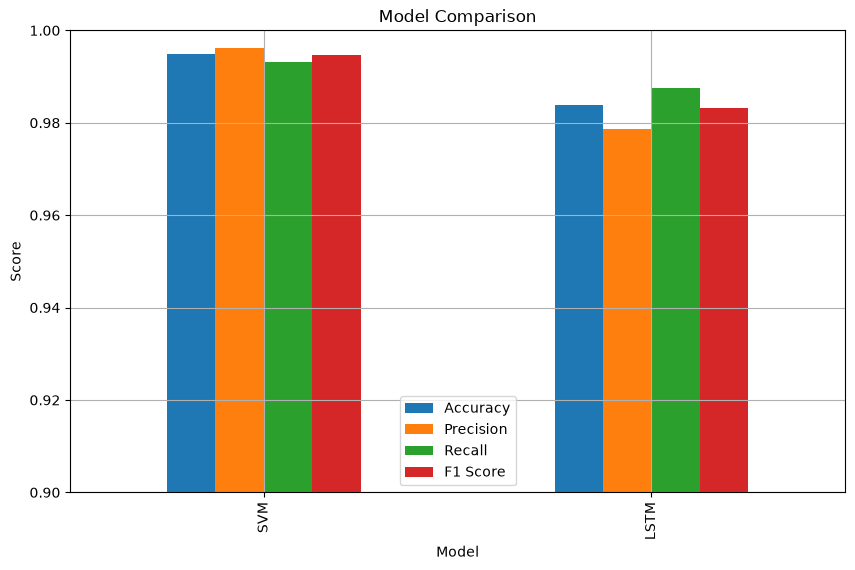

In [13]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Comparison")

plt.ylabel("Score")

plt.ylim(0.9,1.0)

plt.grid(True)

plt.show()

# SVM confustion matrix

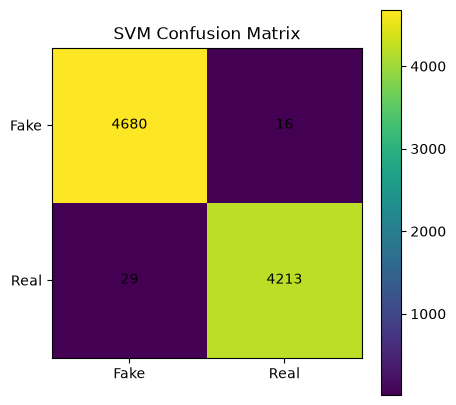

In [14]:
cm = confusion_matrix(
    y_test,
    svm_predictions
)

plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("SVM Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Fake","Real"])
plt.yticks([0,1],["Fake","Real"])

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],
                 ha="center",
                 va="center")

plt.show()

# confution matrix LSTM

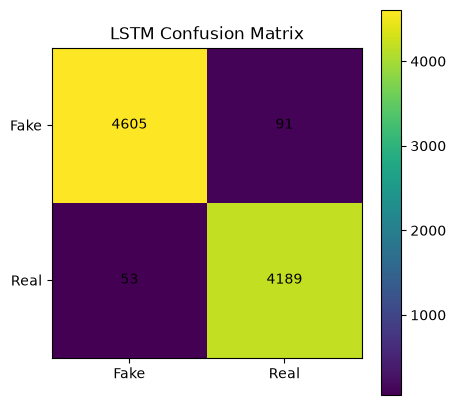

In [15]:
cm = confusion_matrix(
    y_test,
    lstm_predictions
)

plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.title("LSTM Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["Fake","Real"])
plt.yticks([0,1],["Fake","Real"])

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],
                 ha="center",
                 va="center")

plt.show()

# select best one

In [16]:
best = results.sort_values(
    "Accuracy",
    ascending=False
).iloc[0]

print("Best Model")

print(best)

Best Model
Model             SVM
Accuracy     0.994965
Precision    0.996217
Recall       0.993164
F1 Score     0.994688
Name: 0, dtype: object


# Conclusion

This notebook automatically evaluated the SVM and LSTM models using:

- Accuracy
- Precision
- Recall
- F1 Score

The comparison table and graphs were generated automatically.

The best-performing model was selected based on Accuracy and can be integrated into the final Fake News Detection application.